# CIS164 Final Project Notebook Template

This notebook is a **template** showing the recommended structure for your final project.

A good notebook should read like a **story**:
1. What question are you asking?
2. What data are you using?
3. How did you clean and analyze it?
4. What did you find?

Replace the bullet points below with your own content.


# Research Questions

**Research Question**
- Which type of vehicle is involved in the most fatal crashes?

**Why this matters**
People may be interested in knowing what sorts of vehicles are the least safe to drive statistically or at the very least, which vehicle types to avoid the most on the road.

**Research Question**
- Is a drunk driver more likely to kill themselves or another driver?

**Why this matters**
Driving drunk is unsafe. However, some people can justify driving drunk by suggesting that its their life on line, or they may not care so much about their life being on the line. It is therefore important to investigate how much these actions effect other people on the road, and to what extent.

**Research Question**
- Are people who don't wear seatbelts more likely to die in a fatal crash

**Why this matters**
This question has already been determined. In fact, it has been known to be true that people who don't wear seatbelts are more likely to die in a crash. However, many people still don't wear seatbelts. This question is here for those people so that they may clearly see the effects of not wearing a seatbelt.


# Dataset Description

**Dataset Source**
- National Highway Traffic Safety Administration (NHTSA)

The dataset provided by the NHTSA represents all of the accident data from all 52 states in the United States of America. This includes data on who was killed in the crash, the type of vehicle, the blood alcohol content of the drivers, whether or not they were wearing restraints, and a variety of other data.

**Key Variables**
- `State`
- `killed_driver_bac`
- `surviving_driver_bac`
- `vehicle_type`
- `restraint_use`
- `fatality number`
- `fatality percentage`

These variables each take up more than one column of data, but are the general variables of importance for this project.

**Limitations**
- There are 3 missing values in the data
- There is no easy way to replace those values however, 3 out of 1024 data values is negligible 


# Import Libraries

We are using **pandas** for data manipulation and cleaning, **numpy** for statistical operations, and **matplotlib** and **seaborn** for data visualizations and statistical tests.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

The dataset we loaded was from an excel file. We previewed the dataset **vehicle** to ensure that it loaded correctly. The rest of the data was also previewed, but the code for that was removed from this final report to reduce clutter. The comments in the cell below represent the new names of the dataframes after we cleaned them. We will explain how we cleaned them in the next portion of the report. 


In [3]:
event = pd.read_excel("Total Fatal Crashes by Event.xlsx") #Cleaned: crashes_by_event
road_crashes =pd.read_excel("Fatal Crashes by Road.xlsx") #Cleaned: total_road_crashes
fatalities = pd.read_excel("Fatalities.xlsx") #Cleaned: fatalities_by_state
person_killed = pd.read_excel("Person Killed.xlsx") #Cleaned: type_person_killed
road_deaths = pd.read_excel("Total Deaths by Road.xlsx") #Cleaned: total_road_deaths
age = pd.read_excel("Victim Age.xlsx") #Cleaned: victim_age
pedestrians = pd.read_excel("Pedestrian Deaths.xlsx") #Cleaned: pedestrian_deaths
killed_driver_bac = pd.read_excel("Killed Driver BAC.xlsx") #Cleaned: driver_victim_bac
crash_driver_bac = pd.read_excel("Fatal Crash Driver BAC.xlsx") #Cleaned: all_driver_bac
restraint_use = pd.read_excel("Restraint Use Data.xlsx") #Cleaned: restraints
rollover = pd.read_excel("Rollover Data.xlsx") #Cleaned: rollovers
surviving_driver_bac = pd.read_excel("Surviving Driver BAC.xlsx") #Cleaned: living_driver_bac
vehicle = pd.read_excel("Vehicle Type.xlsx") #Cleaned: vehicles
vehicle.head()

,Unnamed: 0,Unnamed: 1,Vehicle Type,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,NaN,NaN,Passenger Cars,NaN,Light Trucks,NaN,Large Trucks,NaN,Buses,NaN,Other Vehicles/Unknown,NaN,Total,NaN,Motorcycles,NaN,Total Occupants Killed
1,State,Number,Percent,Number,Percent,Number,Percent,Number,Percent,Number,Percent,Number,Percent,Number,Percent,Number,Percent
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Alabama,335,40,364,43.4,29,3.5,0,0,16,1.9,744,88.8,94,11.2,838,100
4,Alaska,13,27.1,23,47.9,1,2.1,0,0,3,6.3,40,83.3,8,16.7,48,100


# Data Cleaning

After converting the excel files into dataframes, the first few rows of each dataframe were a mismatched combination of the file labeling system. In other words, the file column names were split into several pieces, amongst several different rows. Thus, we had to fix the column names and remove the first few rows of the data. There was a lot of column names, so to relabel them in a meaningful way, we used a string of code to combine all of the pieces into the full column names, and then reassigned those names to the columns. A secondary problem stemming from the column names having been inserted into the rows of the dataframe was that almost all of our columns were labeled as objects, including the numeric ones. Therefore we also converted all of the columns that were meant to be numeric to numeric data. Lastly, we then created one file containing all of this data. We had to drop overlapping columns to do so. 


In [4]:
event2 = event.iloc[1:].reset_index(drop=True)
for index, val in enumerate(event2.iloc[0]):
    if pd.isna(val):
        event2.iloc[0, index] = event2.iloc[0, index+1]


event2.iloc[2] = event2.iloc[0]+" " + event2.iloc[1]
event2.iloc[2,0] = "State"
event2.columns = event2.iloc[2]
event2.columns.name = None
crashes_by_event = event2.iloc[3:].reset_index(drop=True)
crashes_by_event = crashes_by_event.apply(pd.to_numeric, errors = "ignore")
crashes_by_event8 = crashes_by_event.drop(columns = ["Other Number", "Other Percent", "Unknown Number", "Unknown Percent"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\4282668067.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  crashes_by_event = crashes_by_event.apply(pd.to_numeric, errors = "ignore")


In [5]:
road_crashes.columns = road_crashes.iloc[2] + " Crashes"
road_crashes.columns.name = None
total_road_crashes = road_crashes.iloc[4:].reset_index(drop=True)
total_road_crashes = total_road_crashes.apply(pd.to_numeric, errors = "ignore")
total_road_crashes8 = total_road_crashes.drop(columns=["State Crashes"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\579640847.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  total_road_crashes = total_road_crashes.apply(pd.to_numeric, errors = "ignore")


In [6]:
person_killed2 = person_killed.copy()
for index in range(len(person_killed.columns)-1, 6, -1):
    person_killed2.iloc[0, index] = person_killed.iloc[0, index-2]

person_killed2.iloc[0, 6] = "Motorcyclist"
person_killed2.iloc[0,0] = "State"

for index, val in enumerate(person_killed2.iloc[0]):
    if pd.isna(val):
        person_killed2.iloc[0, index] = person_killed2.iloc[0, index+1]
person_killed2.iloc[2] = person_killed2.iloc[0]+ " " + person_killed2.iloc[1]

person_killed2.columns = person_killed2.iloc[2]
person_killed2.columns.name = None
type_person_killed = person_killed2.iloc[3:].reset_index(drop=True)
type_person_killed.rename(columns = {"State State": "State"}, inplace=True)
type_person_killed = type_person_killed.apply(pd.to_numeric, errors = "ignore")
type_person_killed8 = type_person_killed.drop(columns = ["State", "Other/Unknown Number", "Other/Unknown Percent"])
type_person_killed8 = type_person_killed8[type_person_killed8.columns.dropna()]

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\3972875291.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Total Killed' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  person_killed2.iloc[0, index] = person_killed.iloc[0, index-2]
C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\3972875291.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Total Killed' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  person_killed2.iloc[0, index] = person_killed2.iloc[0, index+1]
C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\3972875291.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  type_person_killed = type_person_killed

In [7]:
road_deaths.columns = road_deaths.iloc[2] + " Deaths"
road_deaths.columns.name = None
total_road_deaths = road_deaths.iloc[4:].reset_index(drop=True)
total_road_deaths = total_road_deaths.apply(pd.to_numeric, errors = "ignore")
total_road_deaths8 = total_road_deaths.drop(columns=["State Deaths"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\2288010528.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  total_road_deaths = total_road_deaths.apply(pd.to_numeric, errors = "ignore")


In [8]:
fatalities_by_state = fatalities.iloc[1:].reset_index(drop=True)
fatalities_by_state8 = fatalities_by_state.drop(columns=["State"])

In [9]:
age.columns = "Age " + age.iloc[0]
age.columns.name = None
victim_age = age.iloc[2:].reset_index(drop=True)
victim_age = victim_age.apply(pd.to_numeric, errors = "ignore")
victim_age8 = victim_age.drop(columns = ["Age State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\4019118734.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  victim_age = victim_age.apply(pd.to_numeric, errors = "ignore")


In [10]:
pedestrian_deaths = pedestrians.iloc[1:].sort_values(by= "State").reset_index(drop=True)
pedestrian_deaths = pedestrian_deaths[["State", "Pedestrians Killed", "Population (Thousands)", "Pedestrian Fatality Rate per 100,000 Population"]]
pedestrian_deaths = pedestrian_deaths.apply(pd.to_numeric, errors = "ignore")
pedestrian_deaths8 = pedestrian_deaths.drop(columns = ["State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\1962759674.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  pedestrian_deaths = pedestrian_deaths.apply(pd.to_numeric, errors = "ignore")


In [11]:
killed_driver_bac2 = killed_driver_bac.copy()

for i, val in enumerate(killed_driver_bac2.iloc[0]):
    if pd.isna(val):
        killed_driver_bac2.iloc[0, i] = killed_driver_bac.iloc[0, i+1]

killed_driver_bac2.iloc[2] = "Victim " + killed_driver_bac2.iloc[0] + " " + killed_driver_bac2.iloc[1]
killed_driver_bac2.iloc[2, 0] = "State"
killed_driver_bac2.columns = killed_driver_bac2.iloc[2]
killed_driver_bac2.columns.name = None

driver_victim_bac = killed_driver_bac2.iloc[3:].reset_index(drop=True)
driver_victim_bac = driver_victim_bac.apply(pd.to_numeric, errors = "ignore")
driver_victim_bac8 = driver_victim_bac.drop(columns = {"Victim Total Drivers Killed Percent", "State"})

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\2097505884.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  driver_victim_bac = driver_victim_bac.apply(pd.to_numeric, errors = "ignore")


In [12]:
cdb = crash_driver_bac.copy()
for i, val in enumerate(crash_driver_bac.iloc[0]):
    if pd.isna(val):
        cdb.iloc[0, i] = crash_driver_bac.iloc[0, i+1]

cdb.iloc[2] = "All " + cdb.iloc[0] +" " + cdb.iloc[1]
cdb.iloc[2, 0] = "State"
cdb.columns = cdb.iloc[2]
cdb.columns.name = None

all_driver_bac = cdb.iloc[3:].reset_index(drop=True)
all_driver_bac = all_driver_bac.apply(pd.to_numeric, errors = "ignore")
all_driver_bac8 = all_driver_bac.drop(columns = {"All Total Drivers Involved in Fatal Crashes Percent", "State"})

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\4227290427.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  all_driver_bac = all_driver_bac.apply(pd.to_numeric, errors = "ignore")


In [13]:
restraint_use2 = restraint_use.copy()
restraint_use2.iloc[1] = restraint_use.columns
for i,val in enumerate(restraint_use2.iloc[1]):
    if val == f"Unnamed: {i}":
        restraint_use2.iloc[1, i] = restraint_use.columns[i+1]

restraint_use2.iloc[1, 0] = "State"
restraint_use2.columns = restraint_use2.iloc[1]+ " "+restraint_use2.iloc[0]
restraint_use2.rename(columns={"State State": 'State', "Total Number": "Restraint Total"}, inplace=True)
restraints = restraint_use2.iloc[2:].reset_index(drop=True)
restraints = restraints.apply(pd.to_numeric, errors = "ignore")
restraints8 = restraints.drop(columns = ["Total Percent", "State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\1585274882.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  restraints = restraints.apply(pd.to_numeric, errors = "ignore")


In [14]:
rollover2 = rollover.copy()
rollover2 = rollover2.drop(columns = ["Unnamed: 13", "Unnamed: 14", "Unnamed: 15"])
rollover3 = rollover2.copy()

for i,val in enumerate(rollover2.iloc[0]):
    if i > 0:
        if pd.isna(val):
            rollover3.iloc[0, i] = rollover2.iloc[0, i-1]
for i,val in enumerate(rollover3.iloc[0]):
    if i > 0:
        if pd.isna(val):
            rollover3.iloc[0, i] = rollover3.iloc[0, i-1]

for i,val in enumerate(rollover2.iloc[1]):
    if i > 0:
        if pd.isna(val):
            rollover3.iloc[1, i] = rollover2.iloc[1, i-1]

rollover3.iloc[0, 0] = "1"
rollover3.iloc[1, 0] = "2"
rollover3.columns = rollover3.iloc[0]+ " "+ rollover3.iloc[1] + " " + rollover3.iloc[2]
rollover3.rename(columns = {"1 2 State": "State", }, inplace=True)

rollovers = rollover3.iloc[4:].reset_index(drop=True)
rollovers = rollovers.apply(pd.to_numeric, errors = "ignore")
rollovers8 = rollovers.drop(columns = ["Passenger Cars Total Num", "Total Total Num", "State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\3209948738.py:25: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  rollovers = rollovers.apply(pd.to_numeric, errors = "ignore")


In [15]:
sdb = surviving_driver_bac.copy()
for i, val in enumerate(surviving_driver_bac.iloc[0]):
    if pd.isna(val):
        sdb.iloc[0, i] = surviving_driver_bac.iloc[0, i+1]

sdb.iloc[2] = "Survivor " + sdb.iloc[0] +" " + sdb.iloc[1]
sdb.iloc[2, 0] = "State"
sdb.columns = sdb.iloc[2]
sdb.columns.name = None

living_driver_bac = sdb.iloc[3:].reset_index(drop=True)
living_driver_bac = living_driver_bac.apply(pd.to_numeric, errors = "ignore")
living_driver_bac8 = living_driver_bac.drop(columns=["Survivor Total Surviving Drivers Involved in Fatal Crashes Percent", "State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\3813712368.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  living_driver_bac = living_driver_bac.apply(pd.to_numeric, errors = "ignore")


In [16]:
v = vehicle.copy()
for i, val in enumerate(vehicle.iloc[0]):
    if pd.isna(val):
        v.iloc[0, i] = vehicle.iloc[0, i+1]

v.iloc[2] = "Vehicle: " + v.iloc[0] +" " + v.iloc[1]
v.iloc[2, 0] = "State"
v.columns = v.iloc[2]
v.columns.name = None

vehicles = v.iloc[3:].reset_index(drop=True)
vehicles = vehicles.apply(pd.to_numeric, errors = "ignore")
vehicles8 = vehicles.drop(columns = {"State"})

C:\Users\marsh\AppData\Local\Temp\ipykernel_29272\1007623987.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  vehicles = vehicles.apply(pd.to_numeric, errors = "ignore")


In [17]:
accident_data_by_state = pd.concat([crashes_by_event, total_road_crashes8, fatalities_by_state8, type_person_killed8, total_road_deaths8, victim_age8, pedestrian_deaths8, driver_victim_bac8, all_driver_bac8, restraints8, rollovers8, living_driver_bac8, vehicles8], axis=1)
accident_data_by_state.to_excel("Accident Data by State.xlsx", index=False)

# Exploratory Data Analysis (EDA)

**Question 1**
 - Which vehicle has the highest mean percentage of fatal accidents?

Light passenger trucks have the highest mean percentage of fatal accidents, with passenger cars not far behind. Busses are notably low, with a mean of only .08% of fatal crashes among US states. Note that this number is the average percentage of all people killed who were in a bus.

**Question 2**
 - How do people with seatbelts compare to people without?

 When considering passenger veichle occupants killed, there is an average of 45% of all people killed in accidents found not wearing seatbelts. Strangely, that number only falls to 42% when considering people found wearing seatbelts.


In [18]:
vehicles.describe()

,Vehicle: Passenger Cars Number,Vehicle: Passenger Cars Percent,Vehicle: Light Trucks Number,Vehicle: Light Trucks Percent,Vehicle: Large Trucks Number,Vehicle: Large Trucks Percent,Vehicle: Buses Number,Vehicle: Buses Percent,Vehicle: Other Vehicles/Unknown Number,Vehicle: Other Vehicles/Unknown Percent,Vehicle: Total Number,Vehicle: Total Percent,Vehicle: Motorcycles Number,Vehicle: Motorcycles Percent,Vehicle: Total Occupants Killed Number,Vehicle: Total Occupants Killed Percent
count,52.000000,52.00000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,453.538462,35.22500,467.961538,38.896154,36.961538,3.309615,1.230769,0.086538,30.538462,2.653846,990.230769,80.175000,243.653846,19.825000,1233.884615,100.0
std,1622.828232,7.70622,1672.184903,6.732361,132.498311,2.253212,4.655233,0.230114,109.458464,2.052207,3538.570669,6.100141,872.808401,6.100141,4410.302069,0.0
min,13.000000,16.90000,4.000000,14.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,57.100000,6.000000,9.200000,27.000000,100.0
25%,70.750000,30.72500,94.000000,35.850000,7.500000,2.100000,0.000000,0.000000,2.750000,1.275000,187.250000,77.375000,38.750000,16.325000,224.250000,100.0
50%,177.000000,34.95000,195.500000,38.100000,15.500000,2.900000,0.000000,0.000000,11.000000,2.350000,396.500000,81.650000,89.500000,18.350000,479.500000,100.0
75%,302.000000,39.55000,310.000000,42.800000,26.250000,4.175000,1.000000,0.000000,23.500000,3.600000,685.750000,83.675000,173.000000,22.625000,840.250000,100.0
max,11792.000000,63.00000,12167.000000,57.000000,961.000000,12.300000,32.000000,1.300000,794.000000,10.700000,25746.000000,90.800000,6335.000000,42.900000,32081.000000,100.0


In [19]:
driver_victim_bac.describe()

,Victim BAC = 0.00 Number,Victim BAC = 0.00 Percent,Victim BAC = .01--.07 Number,Victim BAC = .01--.07 Percent,Victim BAC = .08+ Number,Victim BAC = .08+ Percent,Victim BAC=0.01+ Number,Victim BAC=0.01+ Percent,Victim Total Drivers Killed Number,Victim Total Drivers Killed Percent
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,652.307692,66.153846,43.365385,4.692308,288.269231,29.173077,331.596154,33.865385,983.769231,100.0
std,2329.050733,6.247775,155.159251,1.935615,1032.514105,5.223331,1187.616269,6.212034,3515.804929,0.0
min,10.000000,48.000000,1.000000,1.000000,6.000000,17.000000,9.000000,19.000000,19.000000,100.0
25%,110.250000,63.000000,7.000000,4.000000,36.750000,26.750000,43.500000,30.000000,171.750000,100.0
50%,256.000000,67.000000,14.500000,4.000000,103.500000,29.000000,117.500000,33.000000,382.500000,100.0
75%,461.250000,70.000000,29.250000,5.250000,195.250000,31.250000,216.000000,37.000000,682.750000,100.0
max,16958.000000,81.000000,1126.000000,14.000000,7494.000000,46.000000,8620.000000,52.000000,25578.000000,100.0


In [20]:
living_driver_bac.describe()

,Survivor BAC = 0.00 Number,Survivor BAC = 0.00 Percent,Survivor BAC = .01--.07 Number,Survivor BAC = .01--.07 Percent,Survivor BAC = .08+ Number,Survivor BAC = .08+ Percent,Survivor BAC=0.01+ Number,Survivor BAC=0.01+ Percent,Survivor Total Surviving Drivers Involved in Fatal Crashes Number,Survivor Total Surviving Drivers Involved in Fatal Crashes Percent
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,1037.903846,84.461538,41.980769,3.442308,164.884615,12.019231,206.884615,15.538462,1244.653846,100.0
std,3719.685978,4.345209,151.048296,1.487378,596.207151,3.605499,747.307576,4.345209,4464.593888,0.0
min,27.000000,74.000000,1.000000,1.000000,3.000000,7.000000,4.000000,9.000000,37.000000,100.0
25%,150.750000,81.000000,5.750000,3.000000,16.750000,9.000000,22.750000,12.000000,173.500000,100.0
50%,393.000000,86.000000,13.500000,3.000000,51.500000,11.000000,64.500000,14.000000,451.500000,100.0
75%,663.500000,88.000000,26.250000,4.000000,97.000000,15.000000,128.000000,19.000000,813.750000,100.0
max,26984.000000,91.000000,1091.000000,11.000000,4285.000000,21.000000,5377.000000,26.000000,32361.000000,100.0


In [21]:
all_driver_bac.describe()

,All BAC = 0.00 Number,All BAC = 0.00 Percent,All BAC = .01--.07 Number,All BAC = .01--.07 Percent,All BAC = .08+ Number,All BAC = .08+ Percent,All BAC=0.01+ Number,All BAC=0.01+ Percent,All Total Drivers Involved in Fatal Crashes Number,All Total Drivers Involved in Fatal Crashes Percent
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,1690.057692,76.000000,85.288462,4.057692,453.173077,19.961538,538.403846,24.000000,2228.423077,100.0
std,6047.577932,4.541745,306.108678,1.487378,1627.861339,3.865187,1933.947647,4.541745,7978.977546,0.0
min,37.000000,65.000000,3.000000,2.000000,12.000000,13.000000,18.000000,16.000000,56.000000,100.0
25%,285.000000,73.000000,13.250000,3.000000,53.750000,17.750000,67.250000,21.000000,354.250000,100.0
50%,675.000000,76.500000,28.500000,4.000000,154.000000,19.000000,185.500000,23.500000,847.000000,100.0
75%,1110.250000,79.000000,55.250000,5.000000,285.750000,22.250000,342.000000,27.000000,1484.000000,100.0
max,43943.000000,84.000000,2217.000000,12.000000,11779.000000,31.000000,13996.000000,35.000000,57939.000000,100.0


In [22]:
restraints.describe()

,Restraint Used Number,Restraint Used Percent,Restraint Not Used Number,Restraint Not Used Percent,Restraint Use Unknown Number,Restraint Use Unknown Percent,Restraint Total,Total Percent
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,416.000000,42.103846,403.230769,45.646154,102.269231,12.248077,921.500000,100.0
std,1489.964469,8.663762,1440.651822,8.902268,366.021917,6.500844,3293.996854,0.0
min,2.000000,9.500000,13.000000,30.300000,0.000000,0.000000,21.000000,100.0
25%,60.250000,37.800000,70.000000,38.825000,12.250000,8.775000,170.750000,100.0
50%,165.000000,43.050000,135.000000,44.250000,34.500000,12.000000,364.000000,100.0
75%,265.250000,48.375000,279.500000,51.700000,75.750000,15.225000,624.250000,100.0
max,10816.000000,56.400000,10484.000000,66.300000,2659.000000,28.700000,23959.000000,100.0


# Visualizations

- This boxplot shows the distribution of the total percentage of fatal accidents that each vehicle type accounts for. These percentages are obtained from the statewide rates of every US state.


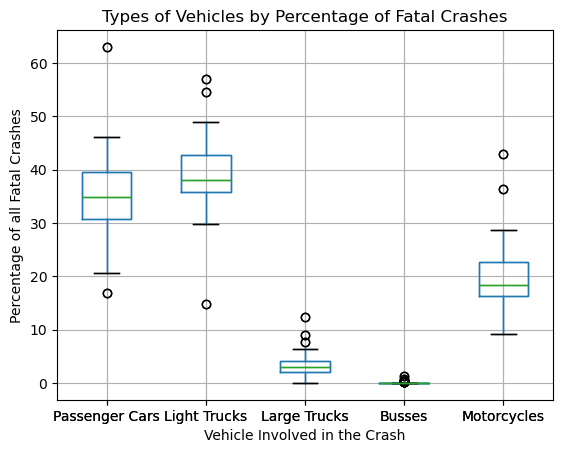

In [32]:
car_type = ["Passenger Car", "Light Truck", "Large Truck", "Bus", "Motorcycle"]
vehicle_percentages = vehicles[["Vehicle: Passenger Cars Percent", "Vehicle: Light Trucks Percent", "Vehicle: Large Trucks Percent", "Vehicle: Buses Percent", "Vehicle: Motorcycles Percent"]]
vehicle_percentages = vehicle_percentages.rename(columns = {"Vehicle: Passenger Cars Percent": "Passenger Cars", "Vehicle: Light Trucks Percent": "Light Trucks", "Vehicle: Large Trucks Percent": "Large Trucks", "Vehicle: Buses Percent": "Busses", "Vehicle: Motorcycles Percent": "Motorcycles"})
vehicle_percentages.boxplot()
plt.title("Types of Vehicles by Percentage of Fatal Crashes")
plt.ylabel("Percentage of all Fatal Crashes")
plt.xlabel("Vehicle Involved in the Crash")
plt.show()

**Interpretation Example**

- Light trucks appear to make up the greatest percent of fatal accidents.
- There is a greater variation in the total percentage of fatal accidents for passenger cars. This suggests that different states have different qualities of drivers or safer laws in place to protect their average car.
- Large trucks and busses always seem to make up a very small portion of the total percentage. It is worth noting that vehicles are much less common on the road though, and this could account for the low rate of fatal crashes.
- Motorcyclists, although less common, still make up a sizeable portion of all fatal crashes. This is particularly evident in two different states, as the boxplot shows outliers as high as 40% of fatal accidents involving motorcycles.


# Key Findings

Summarize the main results.

Example:
- Average sleep duration decreases slightly with age
- Higher depression prevalence appears in younger groups
- The relationship between sleep and depression appears moderate


# Limitations

Discuss weaknesses in the analysis.

Possible examples:
- Small sample size
- Missing data
- Correlation does not imply causation


# Conclusion

Answer the research question directly.

Example:

- There appears to be a **moderate relationship between sleep duration and depression prevalence**
- Further analysis using regression models could explore this relationship more rigorously


# Citations

- National Highway Traffic Safety Administration: https://www-fars.nhtsa.dot.gov/States/StatesOccupants.aspx
- ChatGPT
- Pandas Assistance: https://tutorialreference.com/python/examples/faq/python-pandas-how-to-convert-entire-dataframe-to-numeric-integers-or-floats


## Additional Notes From Class

- The notebook is a critical piece of communication, don't neglect it
- The notebook needs to be easily accessible. Your audience may not be experts in your field and/or the code you've written.
- The notebook needs to be able to run from top-to-bottom.
- Every major step should include **formatted** markdown explaining what you are doing and why.
- This notebook will contain more analyses than you will put in your presentation.
    - That said, remove code that isn't useful or that you were just testing.
- Use meaningful variable names, especially important when you're modifying whole dataframes.
- Label plots, don't rely on defaults
    - Add units to your axes labels if known.